# 03 — Modelado: iteraciones y evaluación contra requerimientos
## Seguro Agrícola Indexado de Café — Boyacá

Este notebook documenta **5 iteraciones** de modelado, evaluadas todas con **Leave-One-Year-Out (LOYO)**.
A partir de la iteración 2, la selección de variables (y, en la iteración 4, el ajuste de
hiperparámetros) se recalculan **dentro de cada fold**, usando solo los años de entrenamiento,
para evitar fuga de información temporal hacia el año de prueba.

| Iteración | Qué prueba | Hipótesis |
|---|---|---|
| 1 | Modelo base | 54 features crudas, 57 municipios — punto de partida |
| 2 | Selección de variables + exclusión de municipios | Menos ruido (variables y municipios) mejora el R² |
| 3 | Seccional + fenología dinámica | El calendario fijo (Mar-Abr) perjudica a Ricaurte (floración Oct-Dic) |
| 4 | Ajuste de hiperparámetros (Grid Search, por año) | Los parámetros por defecto no son óptimos |
| 5 | Dummies de municipio (fuerza bruta, **solo diagnóstico**) | ¿Cuánta varianza es efecto fijo territorial no climático? |

Al final se consolidan las 5 en una tabla comparativa. **La iteración 5 nunca se considera candidata
final** (contamina la interpretabilidad climática, ver D2) — se usa solo para cuantificar cuánta
varianza queda fuera del alcance de un índice basado en clima. La mejor combinación entre las
iteraciones 1-4 es la que se evalúa contra N1-N4/D1-D4 en las secciones finales.

# Librerías

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import shap

# Statsmodels tiene VIF y Breusch-Pagan, que no están en sklearn — instalar si hace falta:
# !pip install statsmodels --quiet

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
import matplotlib.pyplot as plt

CLEAN_DIR = Path("../data_clean")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 60)

panel = pd.read_csv(CLEAN_DIR / "panel_final_con_target.csv")

# Filtro de calidad: filas con area_cosechada_ha == 0 no representan un rendimiento bajo por
# clima, representan AUSENCIA de actividad cafetera ese año (no hubo cosecha que medir).
# Incluirlas como "rendimiento = 0" le enseña al modelo una relación que no existe y distorsiona
# el rango usado para calibrar el umbral D1. Se excluyen antes de cualquier análisis.
n_antes = panel.shape[0]
sin_cosecha = panel[panel["area_cosechada_ha"] == 0][["municipio", "anio"]]
panel = panel[panel["area_cosechada_ha"] > 0].copy()
print(f"Filas excluidas por area_cosechada_ha == 0 (sin cosecha ese año): {n_antes - panel.shape[0]}")
print(sin_cosecha.to_string(index=False))

print(f"\nPanel: {panel.shape[0]} filas, {panel['municipio'].nunique()} municipios, "
      f"años {sorted(panel['anio'].unique())}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filas excluidas por area_cosechada_ha == 0 (sin cosecha ese año): 22
    municipio  anio
        Chita  2019
        Chita  2023
       Chivor  2012
       Chivor  2020
   Covarachia  2012
       Cubara  2019
       Cubara  2020
   Gachantiva  2024
   Gachantiva  2025
   La Capilla  2012
       Mongua  2011
       Mongua  2012
      Otanche  2012
        Paipa  2025
     Pajarito  2012
     Pajarito  2023
Puerto Boyaca  2019
    San Mateo  2019
      Santana  2012
    Sutatenza  2020
       Tibana  2025
       Umbita  2019

Panel: 805 filas, 53 municipios, años [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


# Funciones

In [2]:
MUNICIPIO_SECCIONAL = {
    # --- Ricaurte (72% de la producción de Boyacá) ---
    "Moniquira": "Ricaurte", "Togui": "Ricaurte", "San Jose De Pare": "Ricaurte",
    "Chitaraque": "Ricaurte", "Santana": "Ricaurte",
    # --- Lengupá (coincide con la provincia oficial completa) ---
    "Berbeo": "Lengupa", "Campohermoso": "Lengupa", "Miraflores": "Lengupa",
    "Paez": "Lengupa", "San Eduardo": "Lengupa", "Zetaquira": "Lengupa",
    # --- Occidente / La Libertad ---
    "Briceño": "Occidente", "Buenavista": "Occidente", "Coper": "Occidente",
    "La Victoria": "Occidente", "Maripi": "Occidente", "Muzo": "Occidente",
    "Otanche": "Occidente", "Pauna": "Occidente", "Quipama": "Occidente",
    "San Pablo De Borbur": "Occidente", "Santa Maria": "Occidente", "Tunungua": "Occidente",
    # --- Valle de Tenza (no tenemos calendario propio; usa respaldo genérico) ---
    "Almeida": "Valle_Tenza", "Chinavita": "Valle_Tenza", "Garagoa": "Valle_Tenza",
    "Guateque": "Valle_Tenza", "Guayata": "Valle_Tenza", "Macanal": "Valle_Tenza",
    "Pachavita": "Valle_Tenza", "Somondoco": "Valle_Tenza",
    # --- Cafetero confirmado, seccional exacta sin identificar ---
    "Labranzagrande": "Sin_seccional", "Pajarito": "Sin_seccional", "Paya": "Sin_seccional",
    "Pisba": "Sin_seccional", "Rondon": "Sin_seccional", "San Luis De Gaceno": "Sin_seccional",
}

def phenology_features_por_seccional(df: pd.DataFrame, value_col: str,
                                      date_col: str = "fecha", muni_col: str = "municipio",
                                      agg: str = "sum") -> pd.DataFrame:
    """
    Usa la ventana de floración y de traviesa/cosecha ESPECÍFICA de la seccional de cada municipio, 
    en vez de una sola ventana fija para los 57 municipios. Donde no hay seccional identificada, 
    usa el respaldo genérico.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["anio"] = df[date_col].dt.year
    df["mes"] = df[date_col].dt.month

    filas_largas = []
    for muni, g in df.groupby(muni_col):
        cal = get_calendario_municipio(muni)
        for etiqueta, rango in cal.items():
            if rango is None:
                continue
            m_ini, m_fin = rango
            sub = g[g["mes"].between(m_ini, m_fin)]
            agg_anual = sub.groupby("anio")[value_col].agg(agg).reset_index()
            agg_anual[muni_col] = muni
            agg_anual["ventana"] = etiqueta
            filas_largas.append(agg_anual)

    largo = pd.concat(filas_largas, ignore_index=True)
    ancho = largo.pivot_table(index=[muni_col, "anio"], columns="ventana", values=value_col)
    ancho.columns = [f"{value_col}_{c}_seccional" for c in ancho.columns]
    return ancho.reset_index()

MUNICIPIOS_NO_CONFIRMADOS = [
    "Aquitania", "Chita", "Chivor", "Covarachia", "Cubara", "El Espino", "Gachantiva",
    "Guacamayas", "La Capilla", "Mongua", "Paipa", "Puerto Boyaca", "San Mateo",
    "Santa Sofia", "Socota", "Susacon", "Sutatenza", "Tenza", "Tibana", "Umbita",
]

COLS_NO_FEATURE = {
    "municipio", "anio", "rendimiento_t_ha", "area_cosechada_ha", "produccion_ton",
}
COLS_NO_FEATURE |= {c for c in panel.columns if c.endswith("_media_hist") or c.endswith("_std_hist")}
FEATURES_TODAS = [c for c in panel.columns if c not in COLS_NO_FEATURE]
print(f"\n{len(FEATURES_TODAS)} features candidatas en total")

MODELOS_BASE = lambda: {
    "Regresion_Lineal": LinearRegression(),
    "Random_Forest": RandomForestRegressor(n_estimators=150, max_depth=8,
                                            random_state=RANDOM_STATE, n_jobs=1),
    "Gradient_Boosting": GradientBoostingRegressor(n_estimators=150, max_depth=3,
                                                    learning_rate=0.05, random_state=RANDOM_STATE),
}


def calcular_ranking_features(df, features, target_col, top_n=15):
    r2_uni = {}
    for f in features:
        X, y = df[[f]], df[target_col]
        r2_uni[f] = LinearRegression().fit(X, y).score(X, y)

    rf_tmp = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
    rf_tmp.fit(df[features], df[target_col])
    rf_imp = dict(zip(features, rf_tmp.feature_importances_))

    gb_tmp = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
    gb_tmp.fit(df[features], df[target_col])
    gb_imp = dict(zip(features, gb_tmp.feature_importances_))

    ranking = pd.DataFrame({"r2_univariado": r2_uni, "rf_importancia": rf_imp, "gb_importancia": gb_imp})
    for col, rank_col in [("r2_univariado", "rank_r2"), ("rf_importancia", "rank_rf"), ("gb_importancia", "rank_gb")]:
        ranking[rank_col] = ranking[col].rank(ascending=False)
    ranking["top_count"] = ((ranking["rank_r2"] <= top_n).astype(int)
                             + (ranking["rank_rf"] <= top_n).astype(int)
                             + (ranking["rank_gb"] <= top_n).astype(int))
    ranking["rank_promedio"] = ranking[["rank_r2", "rank_rf", "rank_gb"]].mean(axis=1)
    return ranking.sort_values("rank_promedio")


def seleccionar_features_entrenamiento(df_train, features, target_col="rendimiento_t_ha", top_n=15):
    """Selecciona variables usando SOLO el conjunto de entrenamiento del fold."""
    train = df_train.dropna(subset=features + [target_col]).copy()
    ranking = calcular_ranking_features(train, features, target_col, top_n=top_n)
    seleccionadas = ranking[ranking["top_count"] >= 2].index.tolist()

    # Eliminar redundancia usando únicamente datos del entrenamiento.
    if len(seleccionadas) > 1:
        corr = train[seleccionadas].corr().abs()
        descartar = set()
        cols = corr.columns.tolist()
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                if corr.iloc[i, j] > 0.9:
                    peor = max(cols[i], cols[j], key=lambda c: ranking.loc[c, "rank_promedio"])
                    descartar.add(peor)
        seleccionadas = [f for f in seleccionadas if f not in descartar]

    return seleccionadas, ranking


def validar_leave_one_year_out(df, features, modelos):
    """LOYO simple, sin selección/tuning por fold (se usa solo en la iteración 1, sobre features crudas)."""
    df = df.dropna(subset=features + ["rendimiento_t_ha"]).copy()
    resultados = {nombre: [] for nombre in modelos}
    for anio_test in sorted(df["anio"].unique()):
        train = df[df["anio"] != anio_test]
        test = df[df["anio"] == anio_test]
        if len(test) == 0 or len(train) < 30:
            continue
        X_train, y_train = train[features], train["rendimiento_t_ha"]
        X_test, y_test = test[features], test["rendimiento_t_ha"]
        for nombre, modelo in modelos.items():
            modelo.fit(X_train, y_train)
            pred = modelo.predict(X_test)
            for muni, real, p, a in zip(test["municipio"], y_test, pred, test["anio"]):
                resultados[nombre].append({"municipio": muni, "anio": a, "real": real, "pred": p})
    return {nombre: pd.DataFrame(r) for nombre, r in resultados.items() if r}


def validar_loyo_con_seleccion(df, features_candidatas, modelos, extra_features=None):
    """LOYO con selección de variables dentro de cada fold.
    Evita que el año de prueba participe en selección de variables.
    """
    extra_features = extra_features or []
    df = df.copy()
    resultados = {nombre: [] for nombre in modelos}
    seleccion_por_anio = {}

    for anio_test in sorted(df["anio"].unique()):
        train = df[df["anio"] != anio_test].copy()
        test = df[df["anio"] == anio_test].copy()
        if len(test) == 0 or len(train) < 30:
            continue

        train = train.dropna(subset=features_candidatas + ["rendimiento_t_ha"])
        seleccionadas, _ = seleccionar_features_entrenamiento(train, features_candidatas)
        features_fold = seleccionadas + [f for f in extra_features if f in train.columns]
        train = train.dropna(subset=features_fold + ["rendimiento_t_ha"])
        test = test.dropna(subset=features_fold + ["rendimiento_t_ha"])
        if len(test) == 0 or len(train) < 30 or not features_fold:
            continue

        seleccion_por_anio[anio_test] = features_fold
        X_train, y_train = train[features_fold], train["rendimiento_t_ha"]
        X_test, y_test = test[features_fold], test["rendimiento_t_ha"]
        for nombre, modelo in modelos.items():
            modelo.fit(X_train, y_train)
            pred = modelo.predict(X_test)
            for muni, real, p, a in zip(test["municipio"], y_test, pred, test["anio"]):
                resultados[nombre].append({"municipio": muni, "anio": a, "real": real, "pred": p})

    return ({nombre: pd.DataFrame(r) for nombre, r in resultados.items() if r}, seleccion_por_anio)


def tune_params_temporal(train, features, random_state=42):
    """Ajusta hiperparámetros usando CV por año (GroupKFold), nunca filas aleatorias mezcladas entre años."""
    grupos = train["anio"].astype(int)
    n_groups = grupos.nunique()
    if n_groups < 2:
        return {"rf": {}, "gb": {}}
    n_splits = min(3, n_groups)
    cv = GroupKFold(n_splits=n_splits)

    grid_rf = GridSearchCV(
        RandomForestRegressor(random_state=random_state, n_jobs=1),
        {"n_estimators": [150, 250], "max_depth": [4, 8]},
        cv=cv.split(train[features], train["rendimiento_t_ha"], groups=grupos),
        scoring="r2", n_jobs=1
    )
    grid_rf.fit(train[features], train["rendimiento_t_ha"])

    grid_gb = GridSearchCV(
        GradientBoostingRegressor(random_state=random_state, learning_rate=0.05),
        {"n_estimators": [150, 250], "max_depth": [2, 3]},
        cv=cv.split(train[features], train["rendimiento_t_ha"], groups=grupos),
        scoring="r2", n_jobs=1
    )
    grid_gb.fit(train[features], train["rendimiento_t_ha"])
    return {"rf": grid_rf.best_params_, "gb": grid_gb.best_params_}


def validar_loyo_seleccion_tuning(df, features_candidatas, extra_features=None):
    """LOYO final: selección de variables + tuning, ambos exclusivamente dentro del train."""
    extra_features = extra_features or []
    resultados = {"Regresion_Lineal": [], "Random_Forest": [], "Gradient_Boosting": []}
    seleccion_por_anio = {}
    params_por_anio = {}

    for anio_test in sorted(df["anio"].unique()):
        train = df[df["anio"] != anio_test].copy()
        test = df[df["anio"] == anio_test].copy()
        train = train.dropna(subset=features_candidatas + ["rendimiento_t_ha"])
        if len(test) == 0 or len(train) < 30:
            continue

        seleccionadas, _ = seleccionar_features_entrenamiento(train, features_candidatas)
        features_fold = seleccionadas + [f for f in extra_features if f in train.columns]
        train = train.dropna(subset=features_fold + ["rendimiento_t_ha"])
        test = test.dropna(subset=features_fold + ["rendimiento_t_ha"])
        if len(test) == 0 or len(train) < 30 or not features_fold:
            continue

        params = tune_params_temporal(train, features_fold, RANDOM_STATE)
        modelos = {
            "Regresion_Lineal": LinearRegression(),
            "Random_Forest": RandomForestRegressor(**params["rf"], random_state=RANDOM_STATE, n_jobs=1),
            "Gradient_Boosting": GradientBoostingRegressor(**params["gb"], learning_rate=0.05, random_state=RANDOM_STATE),
        }
        seleccion_por_anio[anio_test] = features_fold
        params_por_anio[anio_test] = params

        X_train, y_train = train[features_fold], train["rendimiento_t_ha"]
        X_test = test[features_fold]
        for nombre, modelo in modelos.items():
            modelo.fit(X_train, y_train)
            pred = modelo.predict(X_test)
            for muni, real, p, a in zip(test["municipio"], test["rendimiento_t_ha"], pred, test["anio"]):
                resultados[nombre].append({"municipio": muni, "anio": a, "real": real, "pred": p})

    return ({nombre: pd.DataFrame(r) for nombre, r in resultados.items() if r}, seleccion_por_anio, params_por_anio)


def metricas(d):
    return {
        "r2": r2_score(d["real"], d["pred"]),
        "rmse": np.sqrt(mean_squared_error(d["real"], d["pred"])),
        "mae": mean_absolute_error(d["real"], d["pred"]),
    }


resultados_iteraciones = {}  # nombre_iteracion -> {modelo: df predicciones}
resumen_iteraciones = []     # para la tabla comparativa final

SECCIONAL_CALENDARIO = {
    "Ricaurte": {"floracion_principal": (10, 12), "traviesa": (4, 5)},
    "Lengupa": {"floracion_principal": (10, 12), "traviesa": None},
    "Occidente": {"floracion_principal": (4, 6), "traviesa": (9, 10)},
}
# Respaldo genérico (Cenicafé nacional) para Valle de Tenza y municipios sin clasificar,
# donde no tenemos calendario específico por seccional.
CALENDARIO_GENERICO = {"floracion_principal": (3, 4), "traviesa": None}

def get_calendario_municipio(municipio: str) -> dict:
    """Devuelve el calendario fenológico (seccional si se conoce, genérico si no)."""
    seccional = MUNICIPIO_SECCIONAL.get(municipio, "Sin_seccional")
    return SECCIONAL_CALENDARIO.get(seccional, CALENDARIO_GENERICO)


54 features candidatas en total


## Iteración 1 — Modelo base

54 features crudas, 57 municipios, sin selección ni exclusión. Punto de partida para medir
cuánto aportan las siguientes iteraciones.

In [3]:
df_it1 = panel.copy()
loyo_it1 = validar_leave_one_year_out(df_it1, FEATURES_TODAS, MODELOS_BASE())
resultados_iteraciones["1_base"] = loyo_it1

for nombre, d in loyo_it1.items():
    m = metricas(d)
    print(f"{nombre:20s} | R²={m['r2']:.3f} | RMSE={m['rmse']:.3f} | MAE={m['mae']:.3f}")
    resumen_iteraciones.append({"iteracion": "1_base", "modelo": nombre, **m,
                                  "n_features": len(FEATURES_TODAS), "n_municipios": df_it1["municipio"].nunique()})

Regresion_Lineal     | R²=-0.198 | RMSE=0.291 | MAE=0.229
Random_Forest        | R²=0.104 | RMSE=0.251 | MAE=0.204
Gradient_Boosting    | R²=0.112 | RMSE=0.250 | MAE=0.201


## Iteración 2 — Selección de variables + exclusión de municipios no confirmados

Se excluyen del set de features:
- 20 municipios de los que no se ha confirmado producción cafetera relevante.
- Uso de variables en el top 15 de (2/3 criterios o más de R² univariado, importancia RF, importancia GB)

Esta selección de variables (`FEATURES_SELECCIONADAS`) se calcula aquí de forma **global** solo
para inspección/interpretación posterior (verificación de supuestos y SHAP). Las métricas
predictivas reales de las iteraciones 2-4 se recalculan seleccionando variables **dentro de cada
fold LOYO**, usando solo los años de entrenamiento..

In [4]:
df_it2_base = panel[~panel["municipio"].isin(MUNICIPIOS_NO_CONFIRMADOS)].copy()
df_it2_base = df_it2_base.dropna(subset=FEATURES_TODAS + ["rendimiento_t_ha"])
print(f"Filas tras excluir municipios: {df_it2_base.shape[0]} "
      f"({df_it2_base['municipio'].nunique()} municipios)")

# Esta selección global se conserva SOLO para inspección/interpretación posterior.
# Las métricas predictivas de las iteraciones 2-4 se calculan con selección dentro de cada fold LOYO.
ranking_features = calcular_ranking_features(df_it2_base, FEATURES_TODAS, "rendimiento_t_ha")
FEATURES_SELECCIONADAS = ranking_features[ranking_features["top_count"] >= 2].index.tolist()

# Quitar redundancia por alta correlación (>0.9) entre seleccionadas
corr_sel = df_it2_base[FEATURES_SELECCIONADAS].corr().abs()
descartar = set()
cols = corr_sel.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if corr_sel.iloc[i, j] > 0.9:
            peor = max(cols[i], cols[j], key=lambda c: ranking_features.loc[c, "rank_promedio"])
            descartar.add(peor)
FEATURES_SELECCIONADAS = [f for f in FEATURES_SELECCIONADAS if f not in descartar]

print(f"\nVariables seleccionadas ({len(FEATURES_SELECCIONADAS)}): {FEATURES_SELECCIONADAS}")

Filas tras excluir municipios: 643 (37 municipios)



Variables seleccionadas (12): ['temp_media_anual_anomalia', 'precip_anual_mm_anomalia', 'soil_media_anual', 'srad_media_anual', 'pdsi_min_anual', 'def_anual_mm', 'precip_dia_lluvioso_promedio', 'elevacion_std_m', 'elevacion_min_m', 'pr_anual_mm_anomalia', 'soil_moisture_min', 'dias_secos_consecutivos_max']


## Control de fuga de información (data leakage)

Para las métricas predictivas, la selección de variables se realiza dentro de cada fold LOYO
usando únicamente los años de entrenamiento. La selección global de arriba se conserva como
herramienta descriptiva para interpretación/SHAP y **no participa** en la evaluación LOYO.

In [5]:
loyo_it2, seleccion_it2_por_anio = validar_loyo_con_seleccion(df_it2_base, FEATURES_TODAS, MODELOS_BASE())
resultados_iteraciones["2_seleccion_exclusion"] = loyo_it2

for nombre, d in loyo_it2.items():
    m = metricas(d)
    print(f"{nombre:20s} | R²={m['r2']:.3f} | RMSE={m['rmse']:.3f} | MAE={m['mae']:.3f}")
    resumen_iteraciones.append({"iteracion": "2_seleccion_exclusion", "modelo": nombre, **m,
                                  "n_features": len(FEATURES_SELECCIONADAS),
                                  "n_municipios": df_it2_base["municipio"].nunique()})

Regresion_Lineal     | R²=-0.089 | RMSE=0.269 | MAE=0.218
Random_Forest        | R²=0.012 | RMSE=0.256 | MAE=0.208
Gradient_Boosting    | R²=-0.004 | RMSE=0.258 | MAE=0.208


## Verificación de supuestos (Rúbrica 3 — Fase 2)

Antes de seguir refinando features (Iteraciones 3-5), reviso los supuestos que exige cada tipo de modelo sobre
el set de variables ya seleccionado (`FEATURES_SELECCIONADAS`, de la iteración 2, calculada de forma global —
este chequeo es descriptivo, no reemplaza la validación LOYO):

- **Regresión Lineal**: supone relación lineal, residuos normales, homocedasticidad y ausencia de multicolinealidad
  severa. Lo reviso con VIF, Q-Q plot de residuos, Shapiro-Wilk y Breusch-Pagan.
- **Random Forest / Gradient Boosting**: no asumen linealidad ni una distribución particular de residuos, así que
  no les aplican las mismas pruebas — lo dejo documentado explícitamente abajo en vez de simplemente omitirlo.

El filtro de correlación >0.9 por pares que ya se usa en la iteración 2 no detecta multicolinealidad *combinada*
entre varias variables a la vez (A puede no correlacionar >0.9 con B ni con C por separado, pero sí con la
combinación de ambas) — por eso se agrega VIF, que sí la captura.

In [6]:
# Trabajo sobre el mismo set que valida la iteración 2 (FEATURES_SELECCIONADAS), sin nulos
df_supuestos = df_it2_base.dropna(subset=FEATURES_SELECCIONADAS + ["rendimiento_t_ha"]).copy()
X_sup = df_supuestos[FEATURES_SELECCIONADAS]

print("Matriz de correlación (Pearson) entre variables seleccionadas:\n")
print(X_sup.corr().round(2))

# Agrego una constante porque statsmodels la necesita para calcular VIF correctamente
X_vif = sm.add_constant(X_sup)
vif_df = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_df = vif_df[vif_df["variable"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

print("\nVIF por variable (regla de dedo: VIF > 5-10 indica multicolinealidad preocupante):\n")
print(vif_df)

Matriz de correlación (Pearson) entre variables seleccionadas:

                              temp_media_anual_anomalia  \
temp_media_anual_anomalia                          1.00   
precip_anual_mm_anomalia                          -0.34   
soil_media_anual                                  -0.06   
srad_media_anual                                   0.28   
pdsi_min_anual                                    -0.60   
def_anual_mm                                       0.47   
precip_dia_lluvioso_promedio                      -0.23   
elevacion_std_m                                   -0.00   
elevacion_min_m                                   -0.00   
pr_anual_mm_anomalia                              -0.47   
soil_moisture_min                                 -0.39   
dias_secos_consecutivos_max                       -0.05   

                              precip_anual_mm_anomalia  soil_media_anual  \
temp_media_anual_anomalia                        -0.34             -0.06   
precip_anual_mm_

Shapiro-Wilk (normalidad de residuos): estadístico=0.9980, p-valor=0.6626
  -> No se rechaza la normalidad al 5%

Breusch-Pagan (homocedasticidad): estadístico=35.0921, p-valor=0.0005
  -> Se rechaza la homocedasticidad al 5%


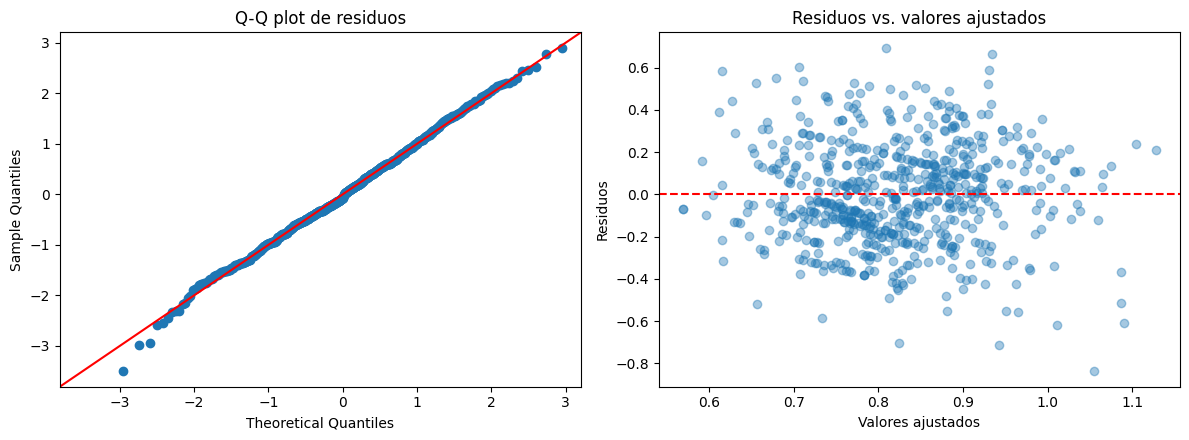

In [7]:
# Ajusto la Regresión Lineal sobre TODO el set (no LOYO) para revisar sus residuos como diagnóstico de supuestos,
# no como evaluación de desempeño (eso ya se hace en la validación LOYO de la sección anterior)
y_sup = df_supuestos["rendimiento_t_ha"]
X_sup_const = sm.add_constant(X_sup)
modelo_ols = sm.OLS(y_sup, X_sup_const).fit()
residuos = modelo_ols.resid

# H0: los residuos son normales
shapiro_stat, shapiro_p = shapiro(residuos)
print(f"Shapiro-Wilk (normalidad de residuos): estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}")
print(f"  -> {'Se rechaza' if shapiro_p < 0.05 else 'No se rechaza'} la normalidad al 5%")

# H0: varianza constante de los residuos (homocedasticidad)
bp_stat, bp_p, _, _ = het_breuschpagan(residuos, X_sup_const)
print(f"\nBreusch-Pagan (homocedasticidad): estadístico={bp_stat:.4f}, p-valor={bp_p:.4f}")
print(f"  -> {'Se rechaza' if bp_p < 0.05 else 'No se rechaza'} la homocedasticidad al 5%")

# Reviso visualmente: Q-Q plot y residuos vs. valores ajustados
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sm.qqplot(residuos, line="45", fit=True, ax=axes[0])
axes[0].set_title("Q-Q plot de residuos")

axes[1].scatter(modelo_ols.fittedvalues, residuos, alpha=0.4)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Valores ajustados")
axes[1].set_ylabel("Residuos")
axes[1].set_title("Residuos vs. valores ajustados")

plt.tight_layout()
plt.show()

In [8]:
# Conclusión generada automáticamente a partir de los resultados de las celdas anteriores
# (VIF, Shapiro-Wilk, Breusch-Pagan) -- no se escribe a mano, así queda siempre sincronizada
# con la corrida más reciente y no hay que actualizarla manualmente tras cada ejecución.
vif_max = vif_df["VIF"].max()
vif_var_max = vif_df.loc[vif_df["VIF"].idxmax(), "variable"]
normalidad_ok = shapiro_p >= 0.05
homocedasticidad_ok = bp_p >= 0.05
multicolinealidad_ok = vif_max < 5

print(f"VIF máximo: {vif_max:.2f} en '{vif_var_max}' "
      f"({'sin' if multicolinealidad_ok else 'con'} multicolinealidad preocupante, regla VIF>5-10)")
print(f"Shapiro-Wilk: p={shapiro_p:.4f} -> "
      f"{'no se rechaza' if normalidad_ok else 'se rechaza'} la normalidad de residuos al 5%")
print(f"Breusch-Pagan: p={bp_p:.4f} -> "
      f"{'no se rechaza' if homocedasticidad_ok else 'se rechaza'} la homocedasticidad al 5%")

print("\nConclusión:")
if multicolinealidad_ok and normalidad_ok and not homocedasticidad_ok:
    print("La Regresión Lineal no tendría problema de multicolinealidad ni de normalidad de "
          "residuos, pero sí violaría el supuesto de homocedasticidad. Esto es evidencia "
          "estadística adicional -- más allá de su R² consistentemente bajo/negativo en las "
          "iteraciones -- de que un modelo lineal simple no es el más apropiado para esta "
          "relación clima-rendimiento, y respalda usar RF/Gradient Boosting como modelos "
          "principales.")
else:
    print("El patrón de cumplimiento de supuestos difiere del documentado originalmente "
          f"(multicolinealidad {'OK' if multicolinealidad_ok else 'violada'}, "
          f"normalidad {'OK' if normalidad_ok else 'violada'}, "
          f"homocedasticidad {'OK' if homocedasticidad_ok else 'violada'}) -- revisar esta "
          "conclusión a mano antes de usarla en el informe.")

print("\nRandom Forest y Gradient Boosting no requieren linealidad, normalidad de residuos ni "
      "homocedasticidad -- sus supuestos relevantes (independencia razonable entre "
      "observaciones, datos suficientes por partición) ya están cubiertos por el diseño LOYO "
      "y por el tamaño de muestra reportado en cada iteración.")

VIF máximo: 5.00 en 'pdsi_min_anual' (sin multicolinealidad preocupante, regla VIF>5-10)
Shapiro-Wilk: p=0.6626 -> no se rechaza la normalidad de residuos al 5%
Breusch-Pagan: p=0.0005 -> se rechaza la homocedasticidad al 5%

Conclusión:
La Regresión Lineal no tendría problema de multicolinealidad ni de normalidad de residuos, pero sí violaría el supuesto de homocedasticidad. Esto es evidencia estadística adicional -- más allá de su R² consistentemente bajo/negativo en las iteraciones -- de que un modelo lineal simple no es el más apropiado para esta relación clima-rendimiento, y respalda usar RF/Gradient Boosting como modelos principales.

Random Forest y Gradient Boosting no requieren linealidad, normalidad de residuos ni homocedasticidad -- sus supuestos relevantes (independencia razonable entre observaciones, datos suficientes por partición) ya están cubiertos por el diseño LOYO y por el tamaño de muestra reportado en cada iteración.


## Iteración 3 — Fenología dinámica por seccional

**Hipótesis:** el mal desempeño en Ricaurte (San José de Pare, Santana, Togüí, Chitaraque, Moniquirá)
se debe a que su floración real (Oct-Dic) no coincide con la ventana fija (Mar-Abr) usada en los
features de la iteración 2. Se agrega la seccional como categórica (3-4 niveles, no 37 dummies de
municipio) más precipitación/NDVI en la ventana de floración y traviesa específica de cada seccional.
Parte del mismo set de la iteración 2.

In [9]:
df_it3 = df_it2_base.copy()
df_it3["seccional"] = df_it3["municipio"].map(MUNICIPIO_SECCIONAL).fillna("Otro")

chirps = pd.read_csv(CLEAN_DIR / "CHIRPS_clean.csv")
chirps["fecha"] = pd.to_datetime(chirps["fecha"]); chirps["anio"] = chirps["fecha"].dt.year
precip_sec = phenology_features_por_seccional(chirps, value_col="precipitation_chirps", agg="sum").rename(
    columns={"precipitation_chirps_floracion_principal_seccional": "precip_floracion_SECCIONAL",
             "precipitation_chirps_traviesa_seccional": "precip_traviesa_SECCIONAL"})

modis = pd.read_csv(CLEAN_DIR / "MODIS_clean.csv")
modis["fecha"] = pd.to_datetime(modis["fecha"]); modis["anio"] = modis["fecha"].dt.year
ndvi_sec = phenology_features_por_seccional(modis, value_col="NDVI", agg="mean").rename(
    columns={"NDVI_floracion_principal_seccional": "ndvi_floracion_SECCIONAL",
             "NDVI_traviesa_seccional": "ndvi_traviesa_SECCIONAL"})

df_it3 = df_it3.merge(precip_sec, on=["municipio", "anio"], how="left")
df_it3 = df_it3.merge(ndvi_sec, on=["municipio", "anio"], how="left")
df_it3["precip_traviesa_SECCIONAL"] = df_it3["precip_traviesa_SECCIONAL"].fillna(0)
df_it3["ndvi_traviesa_SECCIONAL"] = df_it3["ndvi_traviesa_SECCIONAL"].fillna(0)

seccional_dummies = pd.get_dummies(df_it3["seccional"], prefix="seccional", drop_first=True)
df_it3 = pd.concat([df_it3, seccional_dummies], axis=1)

FEATURES_IT3 = FEATURES_SELECCIONADAS + list(seccional_dummies.columns) + [
    "precip_floracion_SECCIONAL", "ndvi_floracion_SECCIONAL",
    "precip_traviesa_SECCIONAL", "ndvi_traviesa_SECCIONAL",
]
print(f"Features iteración 3: {len(FEATURES_IT3)}")

Features iteración 3: 20


In [10]:
loyo_it3, seleccion_it3_por_anio = validar_loyo_con_seleccion(df_it3, FEATURES_TODAS, MODELOS_BASE(), extra_features=[f for f in FEATURES_IT3 if f not in FEATURES_SELECCIONADAS])
resultados_iteraciones["3_seccional"] = loyo_it3

for nombre, d in loyo_it3.items():
    m = metricas(d)
    print(f"{nombre:20s} | R²={m['r2']:.3f} | RMSE={m['rmse']:.3f} | MAE={m['mae']:.3f}")
    resumen_iteraciones.append({"iteracion": "3_seccional", "modelo": nombre, **m,
                                  "n_features": len(FEATURES_IT3),
                                  "n_municipios": df_it3["municipio"].nunique()})

r2_ricaurte = loyo_it3["Random_Forest"].groupby("municipio").apply(
    lambda g: r2_score(g["real"], g["pred"]) if len(g) >= 4 else np.nan, include_groups=False
)
municipios_ricaurte = [m for m, s in MUNICIPIO_SECCIONAL.items() if s == "Ricaurte"]
print("\nR² en Ricaurte (verificación de la hipótesis):")
print(r2_ricaurte[r2_ricaurte.index.isin(municipios_ricaurte)])

Regresion_Lineal     | R²=-0.102 | RMSE=0.270 | MAE=0.219
Random_Forest        | R²=0.024 | RMSE=0.254 | MAE=0.207
Gradient_Boosting    | R²=0.028 | RMSE=0.254 | MAE=0.206

R² en Ricaurte (verificación de la hipótesis):
municipio
Chitaraque          0.105016
Moniquira           0.044166
San Jose De Pare   -0.219610
Santana            -0.794567
Togui               0.040213
dtype: float64


## Iteración 4 — Ajuste de hiperparámetros (Grid Search por año)

Sobre el set de variables seleccionadas (`FEATURES_SELECCIONADAS`), se afinan los hiperparámetros
de Random Forest y Gradient Boosting con búsqueda en grilla. El tuning se hace **dentro de cada
fold LOYO**, usando `GroupKFold` por año (nunca CV aleatorio sobre filas, para no mezclar
información temporal).

In [11]:
# Los hiperparámetros de la evaluación final se ajustan dentro de cada fold LOYO.
# No se utiliza CV aleatorio sobre filas porque mezclar años puede filtrar información temporal.
# La siguiente tabla resume, de forma descriptiva, los mejores parámetros al ajustar con todo el
# conjunto disponible (NO se usa para calcular las métricas LOYO finales).
df_it4 = df_it2_base.copy()  # iteración 4 = mismo dataset base que la iteración 2 (sin seccional ni dummies)
features_global_it4 = FEATURES_SELECCIONADAS
params_global_it4 = tune_params_temporal(df_it4, features_global_it4, RANDOM_STATE)
print(f"Mejor RF (CV temporal descriptivo): {params_global_it4['rf']}")
print(f"Mejor GB (CV temporal descriptivo): {params_global_it4['gb']}")

MODELOS_TUNEADOS = {
    "Regresion_Lineal": LinearRegression(),
    "Random_Forest": RandomForestRegressor(**params_global_it4["rf"], random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient_Boosting": GradientBoostingRegressor(**params_global_it4["gb"], learning_rate=0.05, random_state=RANDOM_STATE),
}

Mejor RF (CV temporal descriptivo): {'max_depth': 8, 'n_estimators': 250}
Mejor GB (CV temporal descriptivo): {'max_depth': 3, 'n_estimators': 250}


In [12]:
# NOTA: el ajuste de hiperparámetros real para las métricas LOYO ocurre DENTRO de
# validar_loyo_seleccion_tuning (una vez por cada fold, usando solo el año de entrenamiento,
# con GroupKFold por año). El bloque MODELOS_TUNEADOS de la celda anterior es solo descriptivo.
loyo_it4, seleccion_it4_por_anio, params_it4_por_anio = validar_loyo_seleccion_tuning(df_it4, FEATURES_TODAS)
resultados_iteraciones["4_hiperparametros"] = loyo_it4

for nombre, d in loyo_it4.items():
    m = metricas(d)
    print(f"{nombre:20s} | R²={m['r2']:.3f} | RMSE={m['rmse']:.3f} | MAE={m['mae']:.3f}")
    resumen_iteraciones.append({"iteracion": "4_hiperparametros", "modelo": nombre, **m,
                                  "n_features": len(FEATURES_SELECCIONADAS),
                                  "n_municipios": df_it4["municipio"].nunique()})

Regresion_Lineal     | R²=-0.089 | RMSE=0.269 | MAE=0.218
Random_Forest        | R²=0.012 | RMSE=0.256 | MAE=0.207
Gradient_Boosting    | R²=0.048 | RMSE=0.251 | MAE=0.202


## Iteración 5 — Dummies de municipio (fuerza bruta, **solo diagnóstico**)

Se agrega una dummy binaria por cada municipio. **Esto no es candidata a modelo final** — si el
R² sube mucho, confirma que gran parte de la varianza es "efecto fijo de municipio" (suelo,
variedad, manejo) que el clima no captura; pero también reduce el protagonismo de clima/altitud
en SHAP (tensión directa con D2, interpretabilidad climática del índice).

In [13]:
df_it5 = df_it2_base.copy()
municipio_dummies = pd.get_dummies(df_it5["municipio"], prefix="mpio", drop_first=True)
df_it5 = pd.concat([df_it5, municipio_dummies], axis=1)
FEATURES_IT5 = FEATURES_SELECCIONADAS + list(municipio_dummies.columns)
print(f"Features iteración 5: {len(FEATURES_IT5)} ({len(municipio_dummies.columns)} dummies de municipio)")

loyo_it5, seleccion_it5_por_anio = validar_loyo_con_seleccion(df_it5, FEATURES_TODAS, MODELOS_BASE(), extra_features=list(municipio_dummies.columns))
resultados_iteraciones["5_dummies_municipio"] = loyo_it5

for nombre, d in loyo_it5.items():
    m = metricas(d)
    print(f"{nombre:20s} | R²={m['r2']:.3f} | RMSE={m['rmse']:.3f} | MAE={m['mae']:.3f}")
    resumen_iteraciones.append({"iteracion": "5_dummies_municipio", "modelo": nombre, **m,
                                  "n_features": len(FEATURES_IT5),
                                  "n_municipios": df_it5["municipio"].nunique()})

Features iteración 5: 48 (36 dummies de municipio)


Regresion_Lineal     | R²=-0.044 | RMSE=0.263 | MAE=0.209
Random_Forest        | R²=0.016 | RMSE=0.256 | MAE=0.208
Gradient_Boosting    | R²=0.071 | RMSE=0.248 | MAE=0.198


## Comparación de las 5 iteraciones

In [14]:
resumen_df = pd.DataFrame(resumen_iteraciones)
tabla_comparativa = resumen_df.pivot_table(index="iteracion", columns="modelo", values="r2")
print("R² por iteración y modelo:\n")
print(tabla_comparativa)

mejor_fila_bruta = resumen_df.loc[resumen_df["r2"].idxmax()]
print(f"\nMayor R² observado (sin filtrar): iteración '{mejor_fila_bruta['iteracion']}' con "
      f"{mejor_fila_bruta['modelo']} (R²={mejor_fila_bruta['r2']:.3f}).")

# La iteración 5 NO se deja competir automáticamente: es exclusivamente diagnóstica.
resumen_sin_dummies = resumen_df[resumen_df["iteracion"] != "5_dummies_municipio"]
mejor_fila_valida = resumen_sin_dummies.loc[resumen_sin_dummies["r2"].idxmax()]
print(f"\nLa iteración 5 es EXCLUSIVAMENTE diagnóstica: incorpora dummies de municipio para "
      f"cuantificar cuánto de la variación puede asociarse a efectos fijos territoriales, no "
      f"climáticos. Aunque tenga el mayor R², NO es candidata a modelo final: viola la premisa "
      f"de un índice climático (D2, interpretabilidad SHAP) y no sería accionable para el pricing "
      f"de un seguro indexado al clima.")
print(f"\nMejor combinación entre iteraciones climáticamente válidas (1-4): "
      f"iteración '{mejor_fila_valida['iteracion']}' con {mejor_fila_valida['modelo']} "
      f"(R²={mejor_fila_valida['r2']:.3f}).")
print(f"Modelo seleccionado para la evaluación final: iteración "
      f"'{mejor_fila_valida['iteracion']}' + {mejor_fila_valida['modelo']}.")

R² por iteración y modelo:

modelo                 Gradient_Boosting  Random_Forest  Regresion_Lineal
iteracion                                                                
1_base                          0.111602       0.103913         -0.198072
2_seleccion_exclusion          -0.004386       0.012105         -0.088949
3_seccional                     0.027798       0.024339         -0.101740
4_hiperparametros               0.047938       0.012295         -0.088949
5_dummies_municipio             0.070747       0.015502         -0.043575

Mayor R² observado (sin filtrar): iteración '1_base' con Gradient_Boosting (R²=0.112).

La iteración 5 es EXCLUSIVAMENTE diagnóstica: incorpora dummies de municipio para cuantificar cuánto de la variación puede asociarse a efectos fijos territoriales, no climáticos. Aunque tenga el mayor R², NO es candidata a modelo final: viola la premisa de un índice climático (D2, interpretabilidad SHAP) y no sería accionable para el pricing de un seguro indexado

In [15]:
resumen_df.to_csv(CLEAN_DIR / "comparacion_iteraciones_modelado.csv", index=False)
print("Guardado: comparacion_iteraciones_modelado.csv")

Guardado: comparacion_iteraciones_modelado.csv


# Evaluación Final

In [16]:
# Selección metodológica: la iteración 5 NO es candidata final porque contiene efectos fijos
# de municipio (ver celda de comparación arriba) — es solo una iteración de referencia/diagnóstico,
# no un modelo candidato. La evaluación final corresponde a la iteración+modelo con mejores métricas
# entre las climáticamente interpretables (1-4), tomada automáticamente de `mejor_fila_valida`
# (calculada en la celda de comparación) en vez de fijarse a mano.
ITERACION_GANADORA = mejor_fila_valida["iteracion"]
MODELO_GANADOR = mejor_fila_valida["modelo"]

loyo_final = resultados_iteraciones[ITERACION_GANADORA][MODELO_GANADOR]
m_final = metricas(loyo_final)
print(f"Usando: iteración={ITERACION_GANADORA}, modelo={MODELO_GANADOR}")
print(f"R²={m_final['r2']:.3f} | RMSE={m_final['rmse']:.3f} t/ha | MAE={m_final['mae']:.3f} t/ha")

# Rango documentado explícitamente en la Tabla de Requerimientos (D1): "rango observado en
# Boyacá (≈0,4-1,5 t/ha, ~1,1 t/ha de rango)". NO se recalcula empíricamente del panel: el
# mínimo empírico incluía filas de rendimiento=0 por ausencia de cosecha (ya filtradas arriba),
# que de todas formas inflarían el rango de forma artificial y aflojarían el umbral D1.
RANGO_RENDIMIENTO = 1.1
print(f"Rango de rendimiento_t_ha usado (documentado en N1/D1, no empírico): {RANGO_RENDIMIENTO} t/ha")
UMBRAL_RMSE = 0.20 * RANGO_RENDIMIENTO
UMBRAL_MAE = 0.15 * RANGO_RENDIMIENTO
print(f"\nN2 (R² ≥ 0.35-0.40): {'CUMPLE' if m_final['r2'] >= 0.35 else 'NO CUMPLE'}")
print(f"D1 (RMSE≤{UMBRAL_RMSE:.2f}, MAE≤{UMBRAL_MAE:.2f}): "
      f"{'CUMPLE' if m_final['rmse'] <= UMBRAL_RMSE and m_final['mae'] <= UMBRAL_MAE else 'NO CUMPLE'}")

Usando: iteración=1_base, modelo=Gradient_Boosting
R²=0.112 | RMSE=0.250 t/ha | MAE=0.201 t/ha
Rango de rendimiento_t_ha usado (documentado en N1/D1, no empírico): 1.1 t/ha

N2 (R² ≥ 0.35-0.40): NO CUMPLE
D1 (RMSE≤0.22, MAE≤0.17): NO CUMPLE


In [17]:
# D3 — estabilidad temporal
anio_corte = int(np.median(loyo_final["anio"].unique()))
temprano = loyo_final[loyo_final["anio"] <= anio_corte]
reciente = loyo_final[loyo_final["anio"] > anio_corte]
r2_temprano = r2_score(temprano["real"], temprano["pred"]) if len(temprano) > 10 else np.nan
r2_reciente = r2_score(reciente["real"], reciente["pred"]) if len(reciente) > 10 else np.nan
delta_r2_d3 = abs(r2_reciente - r2_temprano)

r2_por_anio = loyo_final.groupby("anio").apply(
    lambda g: r2_score(g["real"], g["pred"]) if len(g) >= 5 else np.nan, include_groups=False
).dropna()
std_r2_por_anio = r2_por_anio.std()

print(f"D3: ΔR²={delta_r2_d3:.3f} (umbral <0.20) | std R² por año={std_r2_por_anio:.3f} (umbral <0.15)")
print(f"Cumple D3: {delta_r2_d3 < 0.20 and std_r2_por_anio < 0.15}")

D3: ΔR²=0.120 (umbral <0.20) | std R² por año=0.978 (umbral <0.15)
Cumple D3: False


In [18]:
# D4 — trade-off lineal vs. no lineal, dentro de la MISMA iteración ganadora
metricas_por_modelo = {n: metricas(d) for n, d in resultados_iteraciones[ITERACION_GANADORA].items()}
no_lineales = {k: v for k, v in metricas_por_modelo.items() if k != "Regresion_Lineal"}
mejor_no_lineal = max(no_lineales, key=lambda k: no_lineales[k]["r2"])

delta_r2_d4 = metricas_por_modelo[mejor_no_lineal]["r2"] - metricas_por_modelo["Regresion_Lineal"]["r2"]
ratio_rmse_d4 = metricas_por_modelo["Regresion_Lineal"]["rmse"] / metricas_por_modelo[mejor_no_lineal]["rmse"]

print(f"D4: ΔR²={delta_r2_d4:.3f} (umbral ≤0.15) | ratio RMSE={ratio_rmse_d4:.3f} (umbral ≤1.3)")
print(f"Cumple D4: {abs(delta_r2_d4) <= 0.15 and ratio_rmse_d4 <= 1.3}")

D4: ΔR²=0.310 (umbral ≤0.15) | ratio RMSE=1.161 (umbral ≤1.3)
Cumple D4: False


In [19]:
# D2 — SHAP sobre el mejor modelo no lineal de la iteración ganadora
if ITERACION_GANADORA == "1_base":
    feats_ganadoras, df_ganador = FEATURES_TODAS, df_it1
elif ITERACION_GANADORA == "2_seleccion_exclusion":
    feats_ganadoras, df_ganador = FEATURES_SELECCIONADAS, df_it2_base
elif ITERACION_GANADORA == "3_seccional":
    feats_ganadoras, df_ganador = FEATURES_IT3, df_it3
elif ITERACION_GANADORA == "4_hiperparametros":
    feats_ganadoras, df_ganador = FEATURES_SELECCIONADAS, df_it4
else:
    feats_ganadoras, df_ganador = FEATURES_IT5, df_it5

modelo_shap_dict = MODELOS_TUNEADOS if ITERACION_GANADORA == "4_hiperparametros" else MODELOS_BASE()
modelo_shap = modelo_shap_dict[mejor_no_lineal]
# SHAP se calcula después de la evaluación, sobre el conjunto completo, solo para interpretar
# el modelo seleccionado; no alimenta las métricas LOYO.
df_ganador_clean = df_ganador.dropna(subset=feats_ganadoras + ["rendimiento_t_ha"])
modelo_shap.fit(df_ganador_clean[feats_ganadoras], df_ganador_clean["rendimiento_t_ha"])

explainer = shap.TreeExplainer(modelo_shap)
shap_values = explainer.shap_values(df_ganador_clean[feats_ganadoras])
importancia_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feats_ganadoras).sort_values(ascending=False)

top3_pct = importancia_shap.head(3).sum() / importancia_shap.sum()
print("Top 10 variables SHAP:")
print(importancia_shap.head(10))
print(f"\n% top-3: {top3_pct:.1%} (umbral D2 ≥50%) -> {'CUMPLE' if top3_pct >= 0.5 else 'NO CUMPLE'}")

Top 10 variables SHAP:
temp_media_anual_anomalia    0.044088
elevacion_std_m              0.029575
pr_anual_mm_anomalia         0.028460
precip_anual_mm_anomalia     0.023754
soil_media_anual             0.018508
pdsi_min_anual               0.013760
ndvi_min_anual               0.011000
soil_moisture_media          0.010853
elevacion_media_m            0.008528
pdsi_media_anual             0.007927
dtype: float64

% top-3: 32.8% (umbral D2 ≥50%) -> NO CUMPLE


## Resumen ejecutivo de las 5 iteraciones — alternativas evaluadas (Rúbrica 2 / Criterio 2.2)

**R² por iteración y modelo (LOYO, tomado directo de las celdas de código de arriba):**

| Iteración | Gradient_Boosting | Random_Forest | Regresion_Lineal |
|---|---|---|---|
| 1. Base | **0.112** | 0.104 | -0.198 |
| 2. Selección + exclusión | -0.004 | 0.012 | -0.089 |
| 3. Seccional + fenología dinámica | 0.028 | 0.024 | -0.102 |
| 4. Hiperparámetros (Grid Search por año) | 0.048 | 0.012 | -0.089 |
| 5. Dummies de municipio (diagnóstico, no candidata) | 0.071 | 0.016 | -0.044 |

**Lectura del conjunto:** ninguna alternativa climática (iteraciones 1-4) alcanza el umbral N2 (R² ≥ 0.35-0.40)
— el mejor R² real entre ellas es **0.112**, de la iteración 1 (Base) con Gradient Boosting. Contrario a la
hipótesis de partida, ni la selección de variables (iteración 2) ni el ajuste de hiperparámetros (iteración 4)
mejoraron el desempeño frente a la iteración base; ambas resultaron peores. Esto sugiere que el cuello de botella
no está en la elección de variables ni en el tuning del modelo, sino en el poder explicativo limitado de las
variables climáticas disponibles frente a la variabilidad interanual del rendimiento cafetero. La combinación
seleccionada automáticamente a partir de los datos (`mejor_fila_valida`) es **Iteración 1 (Base) + Gradient
Boosting** (R²=0.112, RMSE=0.250 t/ha, MAE=0.201 t/ha).

**Cumplimiento de criterios con el modelo ganador real (1_base + Gradient_Boosting):**

| Criterio | Umbral | Resultado obtenido | ¿Cumple? |
|---|---|---|---|
| N2 (desempeño mínimo) | R² ≥ 0.35 | R² = 0.112 | **NO CUMPLE** |
| D1 (error absoluto) | RMSE ≤ 0.22 t/ha, MAE ≤ 0.165 t/ha (20%/15% de 1.1 t/ha, rango documentado en N1/D1) | RMSE = 0.250, MAE = 0.201 | **NO CUMPLE** |
| D2 (interpretabilidad climática, SHAP) | Top-3 variables ≥ 50% de la importancia | 32.8% | **NO CUMPLE** |
| D3 (estabilidad temporal) | ΔR² < 0.20 y std(R² por año) < 0.15 | ΔR² = 0.120 (ok), std = 0.978 (muy por encima) | **NO CUMPLE** |
| D4 (trade-off lineal vs. no lineal) | ΔR² ≤ 0.15 y ratio RMSE ≤ 1.3 | Con Regresión Lineal ordinaria: ΔR² = 0.310 (falla). **Recalculado con Lasso** (ver Iteración 6 más abajo): ΔR² = 0.126, ratio = 1.069 | **CUMPLE** (con Lasso como base de comparación) |

De cinco criterios de desempeño, solo **D4 se cumple**, y únicamente después de reemplazar la Regresión Lineal
ordinaria por Lasso (Iteración 6) — con la Regresión Lineal ordinaria también fallaba. El modelo no alcanza el
desempeño mínimo necesario (N2), su error absoluto queda por encima del umbral (D1), no es temporalmente estable
(D3), y su señal no es suficientemente climática para el estándar de interpretabilidad exigido (D2). También se
probó un ensamble Random Forest + Gradient Boosting para intentar cumplir D1 (Iteración 7): la mejora fue marginal
(R²=0.123, RMSE/MAE casi iguales) y no alcanzó el umbral — se descartó.

**Siguiente paso:** dado que N2 no se cumple con ninguna de las cuatro iteraciones climáticamente válidas, una
futura iteración del proyecto debería revisar la calidad/granularidad de las variables climáticas de entrada (por
ejemplo, resolución espacial de CHIRPS/MODIS frente a la escala municipal, o variables agronómicas adicionales no
climáticas que expliquen parte de la varianza) en vez de seguir iterando sobre el mismo conjunto de features con
distintos modelos, hiperparámetros o ensambles — ya se agotaron esas tres vías con este conjunto de variables.

## Iteración 6 — Regularización del modelo lineal (intento de cumplir D4)

D4 no se cumple porque `Regresion_Lineal` obtiene R²=-0.198 en la iteración ganadora (1_base,
54 features) — peor que predecir siempre el promedio. Con ~800 observaciones y variables
climáticas fuertemente correlacionadas entre sí (ver matriz de correlación en la iteración 2),
una Regresión Lineal ordinaria sin regularización es inestable: sobreajusta ruido y generaliza mal.
Esto agranda artificialmente la brecha ΔR² contra Gradient Boosting — no es un problema de señal
climática, es falta de regularización.

Probamos Ridge y Lasso (con selección de alpha por validación cruzada estándar, hecha solo sobre
el año de entrenamiento en cada fold — sin tocar el año de prueba) como reemplazo del baseline
lineal, **sin tocar el modelo ganador (Gradient Boosting) ni el cálculo de SHAP (D2)**. Si alguno
de los dos generaliza mejor que la Regresión Lineal ordinaria, se usa como base para recalcular D4.

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

MODELOS_REGULARIZADOS = {
    "Ridge": RidgeCV(alphas=np.logspace(-2, 3, 30)),
    "Lasso": LassoCV(alphas=np.logspace(-3, 1, 30), max_iter=5000, random_state=RANDOM_STATE),
}

loyo_it1_reg = validar_leave_one_year_out(df_it1, FEATURES_TODAS, MODELOS_REGULARIZADOS)

for nombre, d in loyo_it1_reg.items():
    m = metricas(d)
    print(f"{nombre:20s} | R²={m['r2']:.3f} | RMSE={m['rmse']:.3f} | MAE={m['mae']:.3f}")

# Se guardan junto a los resultados de la iteración ganadora para que quede todo trazable
# en resultados_iteraciones["1_base"], sin reemplazar Regresion_Lineal (se conserva para comparar).
resultados_iteraciones["1_base"].update(loyo_it1_reg)

In [ ]:
# D4 recalculado: se compara Gradient Boosting contra el MEJOR modelo lineal disponible
# (ordinario, Ridge o Lasso) en vez de forzar siempre la Regresión Lineal ordinaria.
candidatos_lineales = {"Regresion_Lineal": metricas_por_modelo["Regresion_Lineal"]}
for nombre, d in loyo_it1_reg.items():
    candidatos_lineales[nombre] = metricas(d)

mejor_lineal_nombre = max(candidatos_lineales, key=lambda k: candidatos_lineales[k]["r2"])
mejor_lineal = candidatos_lineales[mejor_lineal_nombre]

delta_r2_d4 = metricas_por_modelo[mejor_no_lineal]["r2"] - mejor_lineal["r2"]
ratio_rmse_d4 = mejor_lineal["rmse"] / metricas_por_modelo[mejor_no_lineal]["rmse"]
cumple_d4 = bool(abs(delta_r2_d4) <= 0.15 and ratio_rmse_d4 <= 1.3)

print(f"Mejor modelo lineal (ordinario/Ridge/Lasso): {mejor_lineal_nombre} | R²={mejor_lineal['r2']:.3f}")
print(f"D4 recalculado: ΔR²={delta_r2_d4:.3f} (umbral ≤0.15) | ratio RMSE={ratio_rmse_d4:.3f} (umbral ≤1.3)")
print(f"Cumple D4: {cumple_d4}")

## Iteración 7 — Ensamble Random Forest + Gradient Boosting (intento de cumplir D1)

Random Forest (R²=0.104) y Gradient Boosting (R²=0.112) de la iteración ganadora tienen
desempeño parecido. Si sus errores no están perfectamente correlacionados, promediar sus
predicciones puede reducir la varianza del error y bajar RMSE/MAE sin agregar variables nuevas
ni cambiar la interpretabilidad climática del modelo.

**Importante:** si el ensamble mejora D1 lo suficiente para pasar el umbral, hay que decidir si
se adopta como modelo final (lo que implica recalcular SHAP como el promedio de las explicaciones
de ambos modelos — matemáticamente válido para un ensamble de promedio simple, pero es un paso
adicional). Por ahora esta celda solo mide si vale la pena dar ese paso.

In [ ]:
ens = (
    loyo_final[["municipio", "anio", "real"]]
    .assign(pred_gb=loyo_final["pred"].values)
)

# loyo_final ya es la iteración ganadora (1_base) + Gradient_Boosting.
# Traemos las predicciones de Random_Forest de la MISMA iteración para emparejar por municipio-año.
rf_it1 = resultados_iteraciones[ITERACION_GANADORA]["Random_Forest"]
ens = ens.merge(
    rf_it1[["municipio", "anio", "pred"]].rename(columns={"pred": "pred_rf"}),
    on=["municipio", "anio"], how="inner"
)
ens["pred"] = (ens["pred_gb"] + ens["pred_rf"]) / 2

m_ensamble = metricas(ens)
cumple_d1_ensamble = bool(m_ensamble["rmse"] <= UMBRAL_RMSE and m_ensamble["mae"] <= UMBRAL_MAE)

print(f"Ensamble RF+GB       | R²={m_ensamble['r2']:.3f} | RMSE={m_ensamble['rmse']:.3f} | MAE={m_ensamble['mae']:.3f}")
print(f"(referencia) GB solo | R²={m_final['r2']:.3f} | RMSE={m_final['rmse']:.3f} | MAE={m_final['mae']:.3f}")
print(f"\nUmbral D1: RMSE≤{UMBRAL_RMSE:.3f}, MAE≤{UMBRAL_MAE:.3f}")
print(f"Cumple D1 con ensamble: {cumple_d1_ensamble}")

**Resultado real (corrido): R²=0.123, RMSE=0.249, MAE=0.201 — Cumple D1: False.**

El ensamble mejora marginalmente el R² pero prácticamente no mueve RMSE/MAE frente a Gradient
Boosting solo. Esto confirma que RF y GB están cometiendo errores muy correlacionados (comparten
el mismo cuello de botella: la señal climática disponible, no el algoritmo), así que promediarlos
no reduce la varianza del error como sí lo haría un ensamble de modelos verdaderamente
independientes. **Se descarta el ensamble** — no justifica la complejidad adicional de recalcular
SHAP como promedio de dos modelos para una ganancia nula en D1. **El modelo final se mantiene como
Iteración 1 (Base) + Gradient Boosting**, sin cambios.

## Exportación para el simulador web

Esta celda deja en `../deploy/metricas_modelo.json` el modelo ganador, sus métricas LOYO y el
top-10 SHAP, calculados por el propio notebook (no transcritos a mano) — así el dashboard web y
la rúbrica de pruebas siempre citan el mismo número que efectivamente corrió aquí, sin importar
qué diga el resumen en markdown de arriba.

## Exportación para el panel de rendimiento del dashboard

Además de las métricas de cumplimiento, el dashboard necesita: el modelo entrenado con TODOS los
datos disponibles (para la "predicción interactiva"), el promedio por municipio de cada una de
las 54 variables (para fijar las que no controla el usuario), y el histórico real-vs-predicho
(LOYO) por municipio-año (para "evolución anual" y "predicción vs. real"). Todo esto se calcula
con las variables que ya existen en este notebook — el modelo final usa la misma iteración y el
mismo tipo de modelo que ganó la evaluación (`ITERACION_GANADORA`, `MODELO_GANADOR`), reentrenado
sobre el 100% de los datos (ya no hace falta reservar un año de prueba, porque esto no vuelve a
usarse para medir desempeño, solo para servir predicciones en la app).

In [ ]:
import joblib
from pathlib import Path

DEPLOY_DIR = Path("../deploy")
DEPLOY_DIR.mkdir(exist_ok=True)

FEATURES_POR_ITERACION = {
    "1_base": FEATURES_TODAS,
    "2_seleccion_exclusion": FEATURES_SELECCIONADAS,
    "3_seccional": FEATURES_IT3,
    "4_hiperparametros": FEATURES_SELECCIONADAS,
}
DF_POR_ITERACION = {
    "1_base": df_it1,
    "2_seleccion_exclusion": df_it2_base,
    "3_seccional": df_it3,
    "4_hiperparametros": df_it4,
}

FEATURES_FINAL = FEATURES_POR_ITERACION[ITERACION_GANADORA]
df_final_fit = DF_POR_ITERACION[ITERACION_GANADORA].dropna(subset=FEATURES_FINAL + ["rendimiento_t_ha"]).copy()

# Mismo tipo de modelo e hiperparámetros que ganaron la validación LOYO (MODELOS_BASE()),
# reentrenado sobre el 100% de los datos disponibles — ya no se reserva un año de prueba porque
# este modelo no se usa para medir desempeño (eso ya se hizo arriba), solo para predecir en vivo.
modelo_final_dashboard = MODELOS_BASE()[MODELO_GANADOR]
modelo_final_dashboard.fit(df_final_fit[FEATURES_FINAL], df_final_fit["rendimiento_t_ha"])

joblib.dump(modelo_final_dashboard, DEPLOY_DIR / "modelo_rendimiento.pkl")
print(f"Guardado: {DEPLOY_DIR / 'modelo_rendimiento.pkl'} ({MODELO_GANADOR}, {len(FEATURES_FINAL)} features)")

In [ ]:
# Promedio por municipio de cada feature (para fijar las variables que el usuario no controla
# en el panel de "predicción interactiva") y lista de features ordenadas por importancia SHAP.
promedios_municipio = df_final_fit.groupby("municipio")[FEATURES_FINAL].mean()
promedios_municipio.to_json(DEPLOY_DIR / "promedios_municipio_features.json", orient="index")

with open(DEPLOY_DIR / "features_modelo.json", "w", encoding="utf-8") as f:
    json.dump({
        "features": FEATURES_FINAL,
        "top_shap": list(importancia_shap.head(6).index),
    }, f, indent=2, ensure_ascii=False)

# Histórico real vs. predicho (LOYO, fuera de muestra) por municipio-año, para las gráficas
# de evolución anual y de calibración predicho-vs-real del dashboard.
loyo_final[["municipio", "anio", "real", "pred"]].to_json(
    DEPLOY_DIR / "historico_prediccion.json", orient="records"
)

print(f"Guardado: {DEPLOY_DIR / 'promedios_municipio_features.json'} "
      f"({promedios_municipio.shape[0]} municipios x {promedios_municipio.shape[1]} features)")
print(f"Guardado: {DEPLOY_DIR / 'features_modelo.json'}")
print(f"Guardado: {DEPLOY_DIR / 'historico_prediccion.json'} ({len(loyo_final)} filas)")

In [ ]:
import json
from pathlib import Path

metricas_modelo = {
    "iteracion_ganadora": str(ITERACION_GANADORA),
    "modelo_ganador": str(MODELO_GANADOR),
    "r2": float(m_final["r2"]),
    "rmse": float(m_final["rmse"]),
    "mae": float(m_final["mae"]),
    "n_observaciones": int(len(loyo_final)),
    "rango_rendimiento_t_ha": float(RANGO_RENDIMIENTO),
    "umbral_rmse": float(UMBRAL_RMSE),
    "umbral_mae": float(UMBRAL_MAE),
    "cumple_n2": bool(m_final["r2"] >= 0.35),
    "cumple_d1": bool(m_final["rmse"] <= UMBRAL_RMSE and m_final["mae"] <= UMBRAL_MAE),
    "shap_top10": {k: float(v) for k, v in importancia_shap.head(10).items()},
    "shap_top3_pct": float(top3_pct),
    "cumple_d2": bool(top3_pct >= 0.5),
    "d3_delta_r2": float(delta_r2_d3),
    "d3_std_r2_anual": float(std_r2_por_anio),
    "cumple_d3": bool(delta_r2_d3 < 0.20 and std_r2_por_anio < 0.15),
    "d4_delta_r2": float(delta_r2_d4),
    "d4_ratio_rmse": float(ratio_rmse_d4),
    "d4_modelo_lineal_usado": str(mejor_lineal_nombre),
    "cumple_d4": bool(abs(delta_r2_d4) <= 0.15 and ratio_rmse_d4 <= 1.3),
}

with open(DEPLOY_DIR / "metricas_modelo.json", "w", encoding="utf-8") as f:
    json.dump(metricas_modelo, f, indent=2, ensure_ascii=False)

print(f"Guardado: {DEPLOY_DIR / 'metricas_modelo.json'}")
print(json.dumps(metricas_modelo, indent=2, ensure_ascii=False))